# Measure And Compare

Measurements help describe a reconstruction with numbers: how long its branches are, how many branch points it has, and how large it is in x, y, and z.

In this tutorial, you will measure one reconstruction, measure two reconstructions together, and compare an original file with a scaled copy.

## Workflow

```text
sample SWC files
      |
      v
measure one reconstruction
      |
      v
save measurements as JSON
      |
      v
show a short summary table
      |
      v
measure two reconstructions
      |
      v
compare an original file with a scaled copy
```

## Reading the measure commands

A measure command usually starts like this:

```text
swc measure input-file
```

You can give it more than one input file, or save the result to a file.

| Part | Meaning |
| --- | --- |
| `swc measure` | print measurements from SWC files |
| `data/pass_nmo_1.swc` | one input file |
| multiple input files | measure each file in one command |
| `-p 3` | measure only dendrites |
| `-o output/name.json` | save the measurements to a JSON file |
| `swc modify -s 2 2 2` | create a scaled copy for comparison |

## A few measurements to watch

The command prints many values. These are good ones to look at first.

| Measurement | What it means |
| --- | --- |
| `length` | total branch length |
| `area` | surface area |
| `volume` | volume |
| `nbranch` | number of branch points |
| `nterm` | number of terminal endings |
| `xdim`, `ydim`, `zdim` | size of the reconstruction in each direction |

## Command helper

This cell makes the notebook print each command, show the command output, and display generated images.

In [1]:
import json
import subprocess
from pathlib import Path

from IPython.display import Image, Markdown, display


def shell_cmd(command, image=None):
    print("Executed command:")
    print(command)
    result = subprocess.run(
        command,
        shell=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
    )
    output = result.stdout.rstrip()
    print("\nOutput:")
    print(output if output else "(empty)")

    if image is not None and Path(image).exists():
        display(Image(filename=image))


def _format_value(value):
    if value is None:
        return ""
    if isinstance(value, float):
        return f"{value:.4g}"
    return str(value)


def show_measure_table(json_file, features, parts=None):
    with open(json_file) as handle:
        measurements = json.load(handle)

    first_value = next(iter(measurements.values()), {})
    nested_by_file = isinstance(first_value, dict) and not any(
        feature in first_value for feature in features
    )

    if nested_by_file:
        header = ["file", "part", *features]
        rows = []
        for file_name, file_measurements in measurements.items():
            selected_parts = parts or list(file_measurements)
            for part in selected_parts:
                values = file_measurements.get(part, {})
                rows.append(
                    [
                        file_name,
                        part,
                        *[_format_value(values.get(feature)) for feature in features],
                    ]
                )
    else:
        header = ["part", *features]
        selected_parts = parts or list(measurements)
        rows = []
        for part in selected_parts:
            values = measurements.get(part, {})
            rows.append([part, *[_format_value(values.get(feature)) for feature in features]])

    table = ["| " + " | ".join(header) + " |"]
    table.append("| " + " | ".join(["---"] * len(header)) + " |")
    for row in rows:
        table.append("| " + " | ".join(row) + " |")

    display(Markdown("\n".join(table)))


## Copy sample files

Use one NMO reconstruction and two MouseLight reconstructions for the measurement examples. They are copied into `data/` so the tutorial can work with local files.

In [2]:
shell_cmd("cp -v ../tests/data/pass_nmo_1.swc data/")
shell_cmd("cp -v ../tests/data/pass_mouselight_1.swc ../tests/data/pass_mouselight_2.swc data/")

Executed command:
cp -v ../tests/data/pass_nmo_1.swc data/

Output:
'../tests/data/pass_nmo_1.swc' -> 'data/pass_nmo_1.swc'
Executed command:
cp -v ../tests/data/pass_mouselight_1.swc ../tests/data/pass_mouselight_2.swc data/

Output:
'../tests/data/pass_mouselight_1.swc' -> 'data/pass_mouselight_1.swc'
'../tests/data/pass_mouselight_2.swc' -> 'data/pass_mouselight_2.swc'


## Measure one reconstruction

Start by measuring dendrites only. This keeps the first output smaller while still showing the real command output.

In [3]:
shell_cmd("swc measure data/pass_nmo_1.swc -p 3")

Executed command:
swc measure data/pass_nmo_1.swc -p 3

Output:
pass_nmo_1
dend area         9444.9
dend breadth          10
dend contrac    0.927556
dend degree            2
dend diam       0.636772
dend dist         292.67
dend length      5291.67
dend nbranch          30
dend nstem             5
dend nterm            35
dend order             7
dend seclen      81.4102
dend volume      1418.08
dend xdim         537.78
dend ydim         332.53
dend zdim          158.9


## Save measurements

Now save the full measurements to a JSON file. This is the same `swc measure` command, with `-o` added so the result can be reused.

When a command saves its result to a file, the notebook may show `Output: (empty)`. That is normal.

In [4]:
shell_cmd("swc measure data/pass_nmo_1.swc -o output/nmo_1_measure.json")

Executed command:
swc measure data/pass_nmo_1.swc -o output/nmo_1_measure.json

Output:
(empty)


## Read the summary

The table below shows a shorter view of the saved measurements. Empty cells mean that measurement does not apply to that part.

In [5]:
summary_features = ["length", "area", "volume", "nbranch", "nterm", "xdim", "ydim", "zdim"]
show_measure_table("output/nmo_1_measure.json", summary_features)

| file | part | length | area | volume | nbranch | nterm | xdim | ydim | zdim |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| pass_nmo_1 | apic | 5691 | 1.227e+04 | 2331 | 31 | 32 | 452.4 | 760.6 | 157.6 |
| pass_nmo_1 | axon | 4935 | 3595 | 226.4 | 42 | 43 | 890.6 | 466.3 | 147.8 |
| pass_nmo_1 | dend | 5292 | 9445 | 1418 | 30 | 35 | 537.8 | 332.5 | 158.9 |
| pass_nmo_1 | soma |  | 3138 | 9542 |  |  |  |  |  |

## Measure two reconstructions

You can give `swc measure` more than one SWC file. The command measures each file and saves all results together.

In [6]:
shell_cmd("swc measure data/pass_mouselight_1.swc data/pass_mouselight_2.swc -o output/mouselight_measure.json")

Executed command:
swc measure data/pass_mouselight_1.swc data/pass_mouselight_2.swc -o output/mouselight_measure.json

Output:
(empty)


## Compare their numbers

This table makes it easier to compare the same measurements across the two files.

In [7]:
compare_features = ["length", "nbranch", "nterm", "xdim", "ydim", "zdim"]
show_measure_table("output/mouselight_measure.json", compare_features)

| file | part | length | nbranch | nterm | xdim | ydim | zdim |
| --- | --- | --- | --- | --- | --- | --- | --- |
| pass_mouselight_1 | axon | 2.19e+05 | 273 | 274 | 7403 | 2779 | 4018 |
| pass_mouselight_1 | dend | 9331 | 57 | 65 | 291.1 | 370.1 | 929.5 |
| pass_mouselight_1 | soma |  |  |  |  |  |  |
| pass_mouselight_2 | axon | 1.209e+05 | 215 | 216 | 4251 | 4163 | 7399 |
| pass_mouselight_2 | dend | 1.18e+04 | 70 | 80 | 433.5 | 522.9 | 840.8 |
| pass_mouselight_2 | soma |  |  |  |  |  |  |

## Create a scaled copy

To make the comparison easier to understand, create a copy where x, y, and z are all scaled by a factor of 2.

In [8]:
shell_cmd("swc modify data/pass_nmo_1.swc -s 2 2 2 -o output/scaled.swc")

Executed command:
swc modify data/pass_nmo_1.swc -s 2 2 2 -o output/scaled.swc

Output:
(empty)


## View original and scaled files

Before comparing numbers, look at the two reconstructions together.

Executed command:
swc view data/pass_nmo_1.swc output/scaled.swc -c cells -o output/measure_compare.png

Output:
(empty)


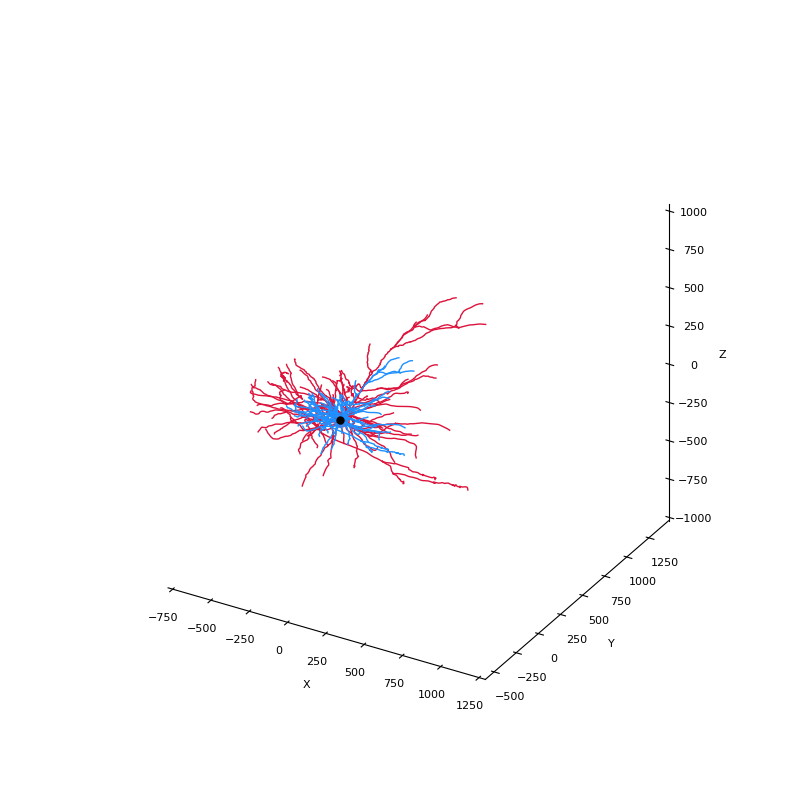

In [9]:
shell_cmd("swc view data/pass_nmo_1.swc output/scaled.swc -c cells -o output/measure_compare.png", 
          image="output/measure_compare.png")

## Measure original and scaled files

Now measure both files. Because the scaled file is twice as large in x, y, and z, size measurements such as length, area, volume, and dimensions should increase. Note that scaling is not applied to soma dimensions.

In [10]:
shell_cmd("swc measure data/pass_nmo_1.swc output/scaled.swc -o output/scaled_measure.json")

Executed command:
swc measure data/pass_nmo_1.swc output/scaled.swc -o output/scaled_measure.json

Output:
(empty)


## Compare before and after scaling

This final table shows how the measurements changed after scaling. Branch counts stay the same, while geometric measurements become larger.

In [11]:
scaled_features = ["length", "area", "volume", "nbranch", "nterm", "xdim", "ydim", "zdim"]
show_measure_table("output/scaled_measure.json", scaled_features)

| file | part | length | area | volume | nbranch | nterm | xdim | ydim | zdim |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| pass_nmo_1 | apic | 5691 | 1.227e+04 | 2331 | 31 | 32 | 452.4 | 760.6 | 157.6 |
| pass_nmo_1 | axon | 4935 | 3595 | 226.4 | 42 | 43 | 890.6 | 466.3 | 147.8 |
| pass_nmo_1 | dend | 5292 | 9445 | 1418 | 30 | 35 | 537.8 | 332.5 | 158.9 |
| pass_nmo_1 | soma |  | 3138 | 9542 |  |  |  |  |  |
| scaled | apic | 1.131e+04 | 2.428e+04 | 4582 | 31 | 32 | 900.1 | 1510 | 313.2 |
| scaled | axon | 9380 | 6793 | 410.4 | 42 | 43 | 1706 | 917.9 | 294.7 |
| scaled | dend | 1.045e+04 | 1.851e+04 | 2734 | 30 | 35 | 1051 | 657.1 | 307.3 |
| scaled | soma |  | 3138 | 9542 |  |  |  |  |  |